In [1]:
%load_ext autoreload
%autoreload 2

In [16]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

In [6]:
dag_path        = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit"
hese_path       = f"{dag_path}/hese/"
hese_syst_path       = f"{dag_path}/hese/systematics/third_benchmark"

scan_dir_dict = {
    # --- HESE spice ----
    "hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice": f"{hese_path}/spice/hese_HESEBestfit_SPL_noinel_nosyst_Poisson",
    "hese_SPL_noinel_nosyst_Poisson_spice": f"{hese_path}/spice/hese_SPL_noinel_nosyst_Poisson",

    # --- HESE ----
    "hese_HESEBestfit_SPL_noinel_nosyst_Poisson": f"{hese_path}/Poisson/hese_HESEBestfit_SPL_noinel_nosyst",
    "hese_SPL_noinel_nosyst_Poisson":             f"{hese_path}/Poisson/hese_SPL_noinel_nosyst",
    "hese_BPL_noinel_nosyst_Poisson":             f"{hese_path}/Poisson/hese_BPL_noinel_nosyst",

    "hese_HESEBestfit_SPL_noinel_nosyst_SAY": f"{hese_path}/SAY/hese_HESEBestfit_SPL_noinel_nosyst",
    "hese_SPL_noinel_nosyst_SAY":             f"{hese_path}/SAY/hese_SPL_noinel_nosyst",
    "hese_BPL_noinel_nosyst_SAY":             f"{hese_path}/SAY/hese_BPL_noinel_nosyst",

    "hese_HESEBestfit_SPL_noineltrue_nosyst_SAY": f"{hese_path}/SAY/hese_HESEBestfit_SPL_noineltrue_nosyst",
    "hese_SPL_noineltrue_nosyst_SAY":             f"{hese_path}/SAY/hese_SPL_noineltrue_nosyst",
    "hese_BPL_noineltrue_nosyst_SAY":             f"{hese_path}/SAY/hese_BPL_noineltrue_nosyst",

    # adding inelasticity
    "hese_HESEBestfit_SPL_nosyst_Poisson": f"{hese_path}/Poisson/hese_HESEBestfit_SPL_nosyst",
    "hese_SPL_nosyst_Poisson":             f"{hese_path}/Poisson/hese_SPL_nosyst",
    "hese_BPL_nosyst_Poisson":             f"{hese_path}/Poisson/hese_BPL_nosyst",

    "hese_HESEBestfit_SPL_nosyst_SAY": f"{hese_path}/SAY/hese_HESEBestfit_SPL_nosyst",
    "hese_SPL_nosyst_SAY":             f"{hese_path}/SAY/hese_SPL_nosyst",
    "hese_BPL_nosyst_SAY":             f"{hese_path}/SAY/hese_BPL_nosyst",

    # --- HESE systematics ----
    "hese_HESEBestfit_SPL_SAY": f"{hese_syst_path}/SAY/hese_HESEBestfit_SPL",
    "hese_SPL_SAY":             f"{hese_syst_path}/SAY/hese_SPL",
    "hese_BPL_SAY":             f"{hese_syst_path}/SAY/hese_BPL",

    "hese_HESEBestfit_SPL_noinel_SAY": f"{hese_syst_path}/SAY/hese_HESEBestfit_SPL_noinel",
    "hese_SPL_noinel_SAY":             f"{hese_syst_path}/SAY/hese_SPL_noinel",
    "hese_BPL_noinel_SAY":             f"{hese_syst_path}/SAY/hese_BPL_noinel",

}

In [26]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/presentations/2026-04-08_diffuse_update/hese"
os.system(f"mkdir -p {plotting_path}")

0

In [7]:
# load the data
N_grid = 40 # 20 was standard
drop_unsuccessful = False
scan_dict = {}
data = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "newflavorparam" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=N_grid)


hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//spice/hese_HESEBestfit_SPL_noinel_nosyst_Poisson
removed stuff
hese_SPL_noinel_nosyst_Poisson_spice
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//spice/hese_SPL_noinel_nosyst_Poisson
removed stuff
hese_HESEBestfit_SPL_noinel_nosyst_Poisson
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//Poisson/hese_HESEBestfit_SPL_noinel_nosyst
removed stuff
hese_SPL_noinel_nosyst_Poisson
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//Poisson/hese_SPL_noinel_nosyst
removed stuff
hese_BPL_noinel_nosyst_Poisson
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese//Poisson/hese_BPL_noinel_nosyst
removed stuff
hese_HESEBestfit_SPL_noinel_nosyst_SAY
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit

First final plots

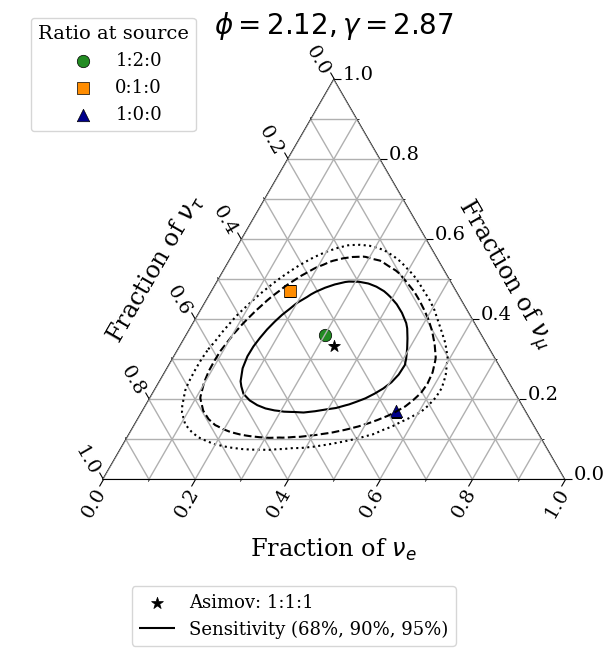

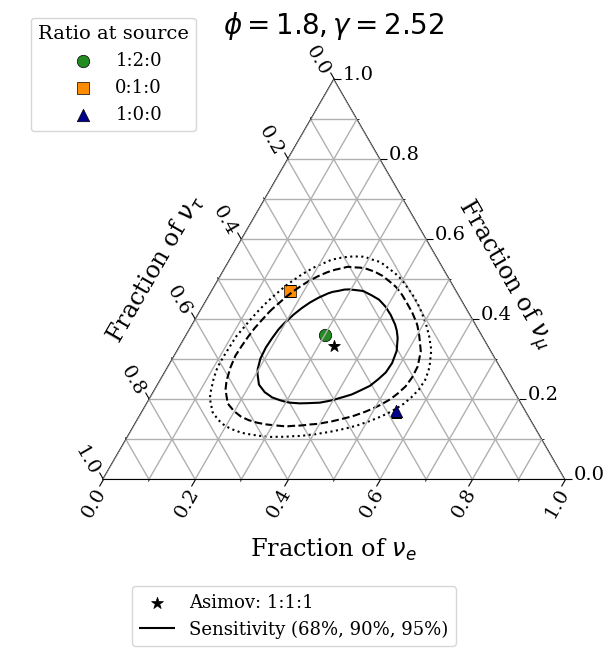

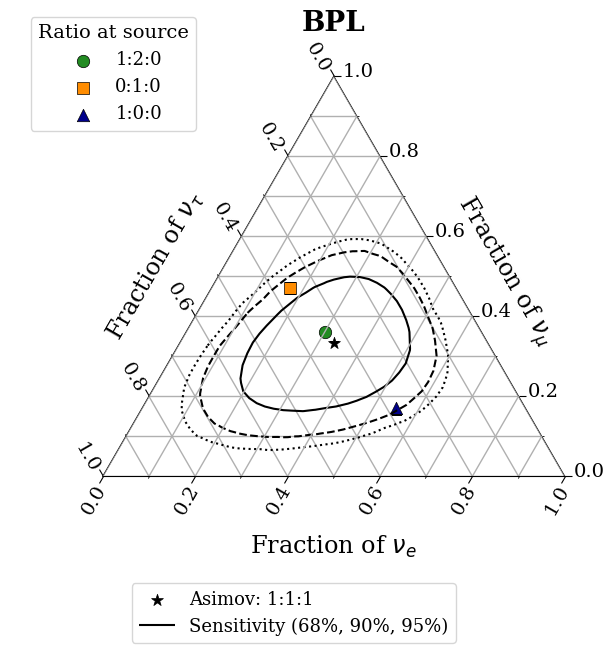

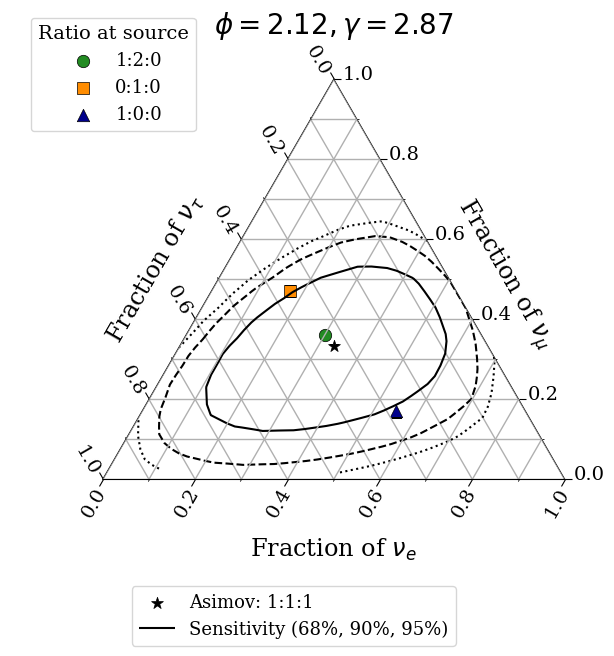

In [27]:
for name, title in zip(["hese_HESEBestfit_SPL_noinel_SAY", "hese_SPL_noinel_SAY", "hese_BPL_noinel_SAY","hese_HESEBestfit_SPL_noinel_nosyst_Poisson_spice"],
                       [r"$\phi=2.12,\gamma=2.87$",r"$\phi=1.8,\gamma=2.52$",r"BPL",r"$\phi=2.12,\gamma=2.87$"]):

    C = plot_contour( data = data,
                    name = name,
                    label = "Sensitivity",
                    levels = ["68%","90%","95%"],
                    title = title,
                    scenarios=True,
                    show_ts_labels=False,
                    savepath = f"{plotting_path}/{name}.png")


Now some comparison plots

/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_HESEBestfit_SPL_noinel_SAY / hese_HESEBestfit_SPL_noinel_SAY) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_SAY / hese_HESEBestfit_SPL_noinel_SAY) at 68%: 1.0287


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_SPL_noinel_SAY / hese_SPL_noinel_SAY) at 68%: 1.0000
Area ratio (hese_SPL_SAY / hese_SPL_noinel_SAY) at 68%: 1.0247


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_BPL_noinel_SAY / hese_BPL_noinel_SAY) at 68%: 1.0000
Area ratio (hese_BPL_SAY / hese_BPL_noinel_SAY) at 68%: 1.0252


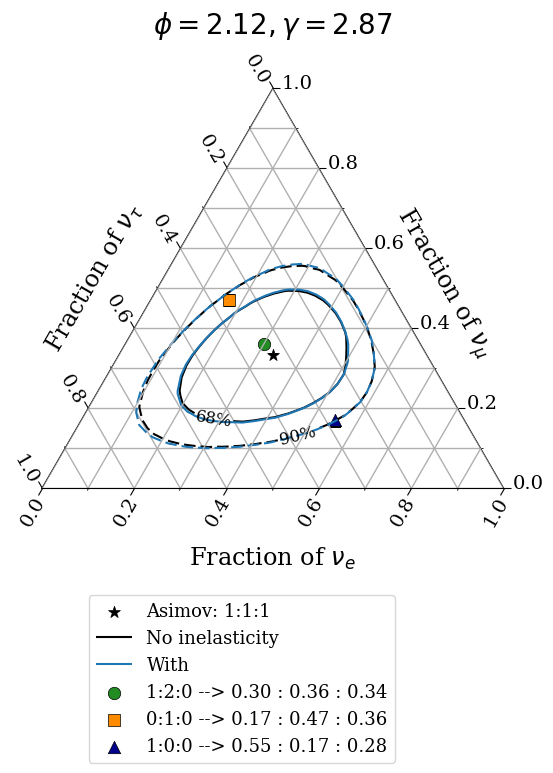

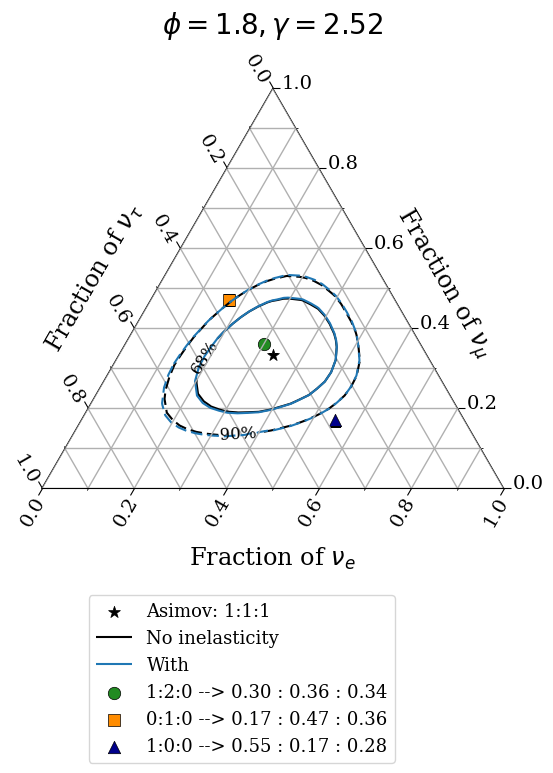

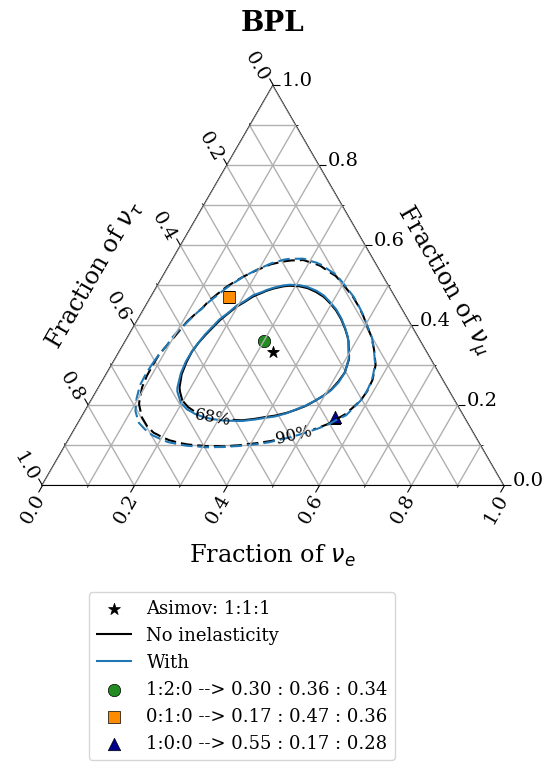

In [28]:
for flux, title in zip(["HESEBestfit_SPL", "SPL", "BPL"],
                       [r"$\phi=2.12,\gamma=2.87$",r"$\phi=1.8,\gamma=2.52$",r"BPL"]):

    savename = f"compare_inel_hese_{flux}_SAY"
    names = [
    f"hese_{flux}_noinel_SAY",
    f"hese_{flux}_SAY",
    ]
    labels = [
        "No inelasticity",
        "With",
    ]
    C = compare_contours( data = data,
                    names = names,
                    labels = labels,
                    levels = ["68%", "90%"],
                    title = title,
                    scenarios = True,
                    show_ts_labels=True,
                    savepath = f"{plotting_path}/{savename}.png")

    for name in names: compare_area( C, alt_key=name, base_key=names[0], levels=["68%"] )

/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_HESEBestfit_SPL_noineltrue_nosyst_SAY / hese_HESEBestfit_SPL_noineltrue_nosyst_SAY) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_noinel_SAY / hese_HESEBestfit_SPL_noineltrue_nosyst_SAY) at 68%: 1.0554


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_SPL_noineltrue_nosyst_SAY / hese_SPL_noineltrue_nosyst_SAY) at 68%: 1.0000
Area ratio (hese_SPL_noinel_SAY / hese_SPL_noineltrue_nosyst_SAY) at 68%: 1.0968


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_BPL_noineltrue_nosyst_SAY / hese_BPL_noineltrue_nosyst_SAY) at 68%: 1.0000
Area ratio (hese_BPL_noinel_SAY / hese_BPL_noineltrue_nosyst_SAY) at 68%: 1.0638


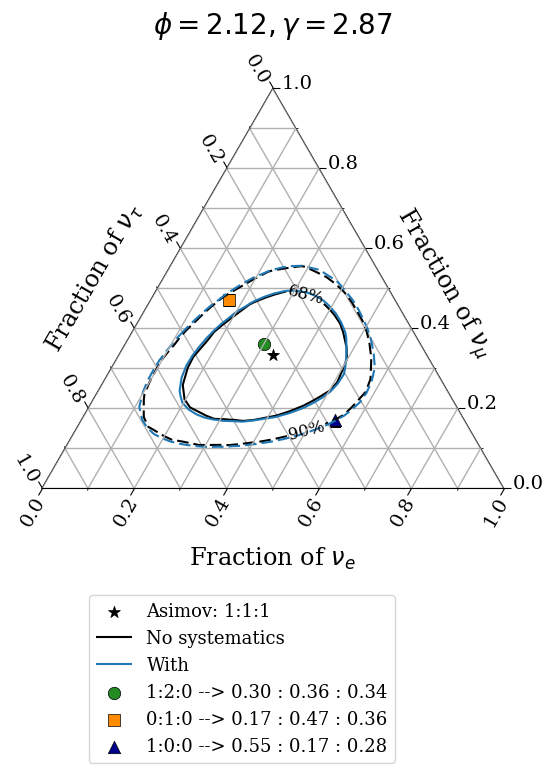

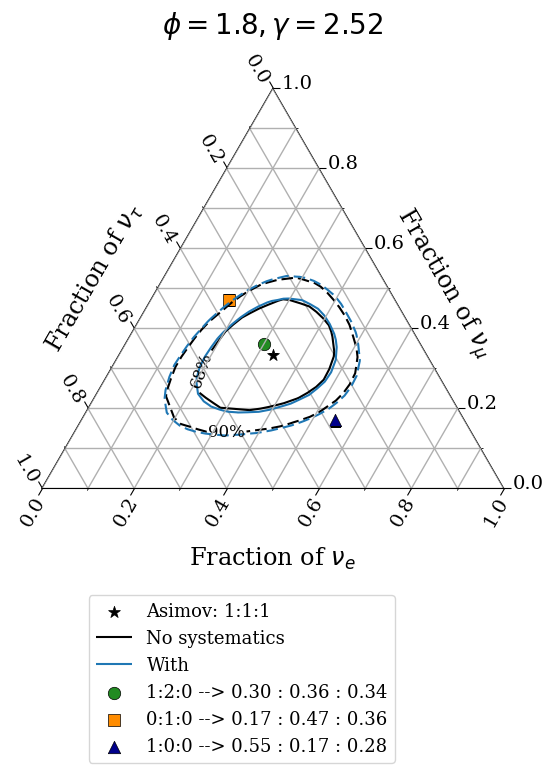

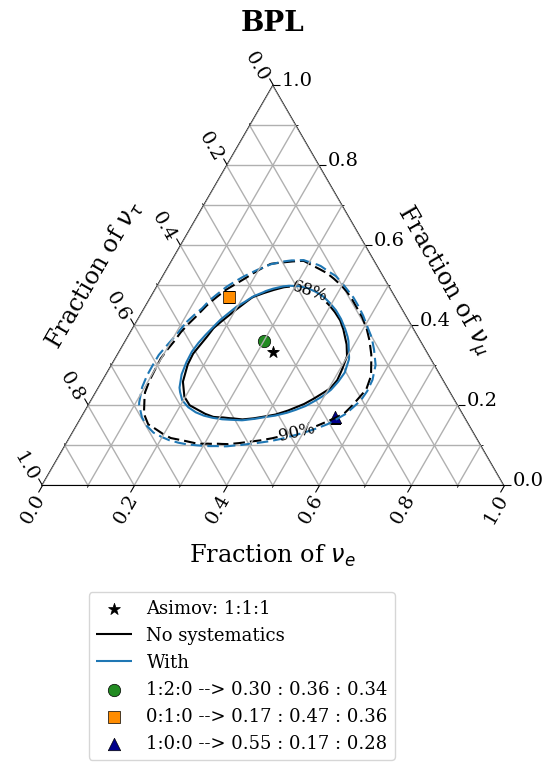

In [29]:
for flux, title in zip(["HESEBestfit_SPL", "SPL", "BPL"],
                       [r"$\phi=2.12,\gamma=2.87$",r"$\phi=1.8,\gamma=2.52$",r"BPL"]):

    savename = f"compare_syst_hese_{flux}_SAY"
    names = [
    f"hese_{flux}_noineltrue_nosyst_SAY",
    f"hese_{flux}_noinel_SAY",
    ]
    labels = [
        "No systematics",
        "With",
    ]
    C = compare_contours( data = data,
                    names = names,
                    labels = labels,
                    levels = ["68%", "90%"],
                    title = title,
                    scenarios = True,
                    show_ts_labels=True,
                    savepath = f"{plotting_path}/{savename}.png")

    for name in names: compare_area( C, alt_key=name, base_key=names[0], levels=["68%"] )

/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_HESEBestfit_SPL_nosyst_Poisson / hese_HESEBestfit_SPL_nosyst_Poisson) at 68%: 1.0000
Area ratio (hese_HESEBestfit_SPL_nosyst_SAY / hese_HESEBestfit_SPL_nosyst_Poisson) at 68%: 1.0000


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_SPL_nosyst_Poisson / hese_SPL_nosyst_Poisson) at 68%: 1.0000
Area ratio (hese_SPL_nosyst_SAY / hese_SPL_nosyst_Poisson) at 68%: 1.0086


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

Area ratio (hese_BPL_nosyst_Poisson / hese_BPL_nosyst_Poisson) at 68%: 1.0000
Area ratio (hese_BPL_nosyst_SAY / hese_BPL_nosyst_Poisson) at 68%: 0.9998


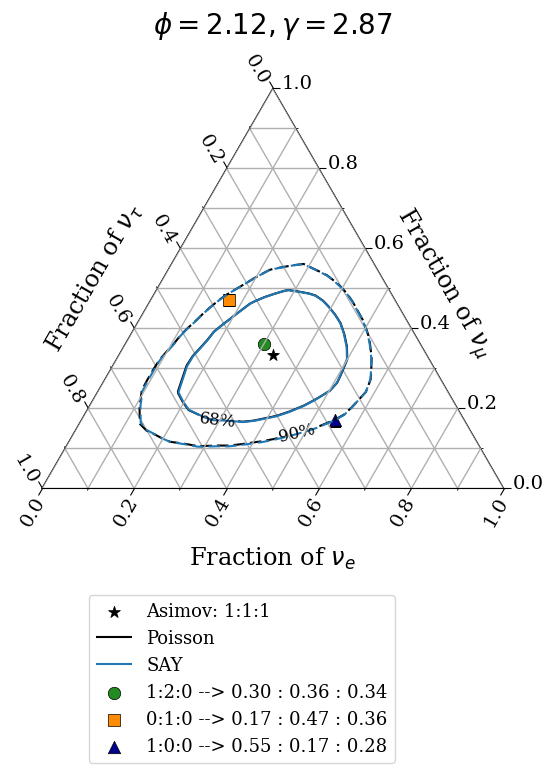

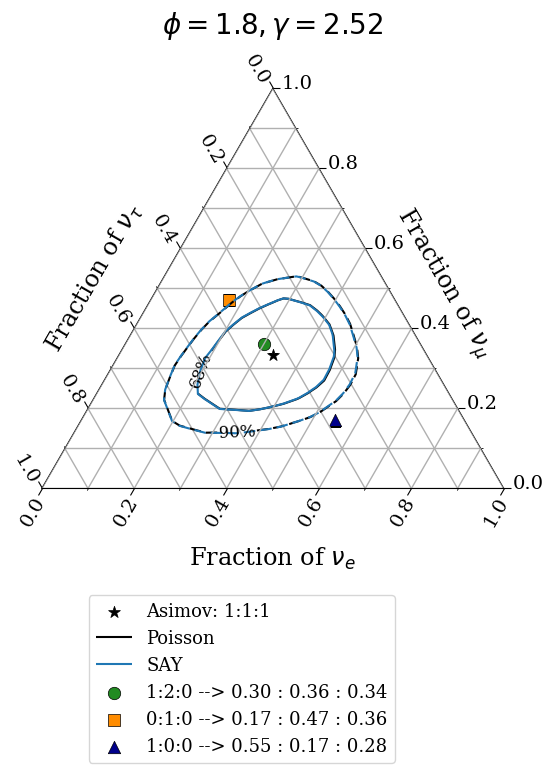

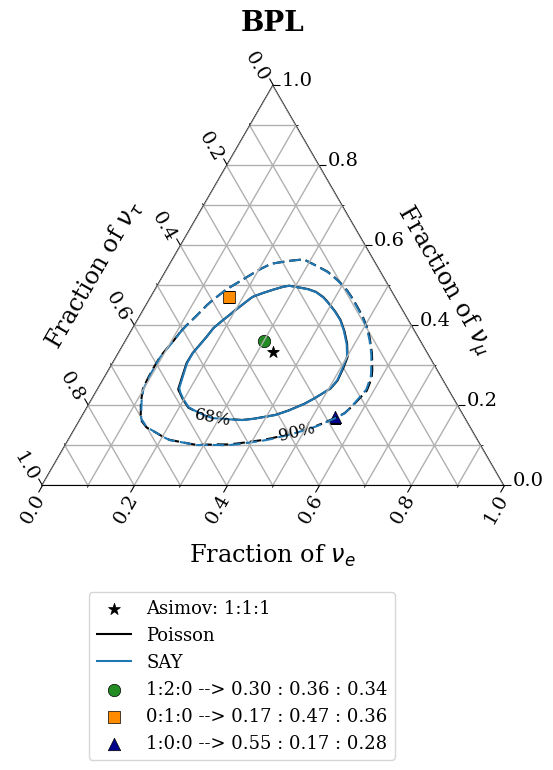

In [30]:
for flux, title in zip(["HESEBestfit_SPL", "SPL", "BPL"],
                       [r"$\phi=2.12,\gamma=2.87$",r"$\phi=1.8,\gamma=2.52$",r"BPL"]):

    savename = f"compare_lik_hese_{flux}_nosyst"
    names = [
    f"hese_{flux}_nosyst_Poisson",
    f"hese_{flux}_nosyst_SAY",
    ]
    labels = [
        "Poisson",
        "SAY",
    ]
    C = compare_contours( data = data,
                    names = names,
                    labels = labels,
                    levels = ["68%", "90%"],
                    title = title,
                    scenarios = True,
                    show_ts_labels=True,
                    savepath = f"{plotting_path}/{savename}.png")

    for name in names: compare_area( C, alt_key=name, base_key=names[0], levels=["68%"] )

Area ratio (hese_HESEBestfit_SPL_noinel_SAY / hese_HESEBestfit_SPL_noinel_SAY) at 68%: 1.0000
Area ratio (hese_SPL_noinel_SAY / hese_HESEBestfit_SPL_noinel_SAY) at 68%: 0.7335
Area ratio (hese_BPL_nosyst_SAY / hese_HESEBestfit_SPL_noinel_SAY) at 68%: 1.0049


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

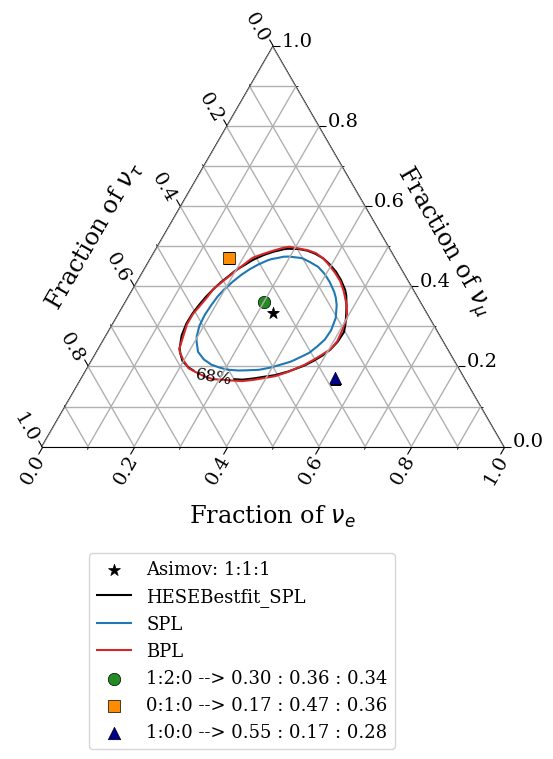

In [33]:
savename = f"compare_allflux_hese_noinel"
names = [
f"hese_HESEBestfit_SPL_noinel_SAY",
f"hese_SPL_noinel_SAY",
f"hese_BPL_nosyst_SAY",
]
labels = [
    "HESEBestfit_SPL",
    "SPL",
    "BPL",
]
C = compare_contours( data = data,
                names = names,
                labels = labels,
                levels = ["68%"],
                title = "",
                scenarios = True,
                show_ts_labels=True,
                savepath = f"{plotting_path}/{savename}.png")

for name in names: compare_area( C, alt_key=name, base_key=names[0], levels=["68%"] )

Area ratio (hese_HESEBestfit_SPL_noinel_SAY / hese_HESEBestfit_SPL_noinel_SAY) at 68%: 1.0000
Area ratio (hese_BPL_nosyst_SAY / hese_HESEBestfit_SPL_noinel_SAY) at 68%: 1.0049


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

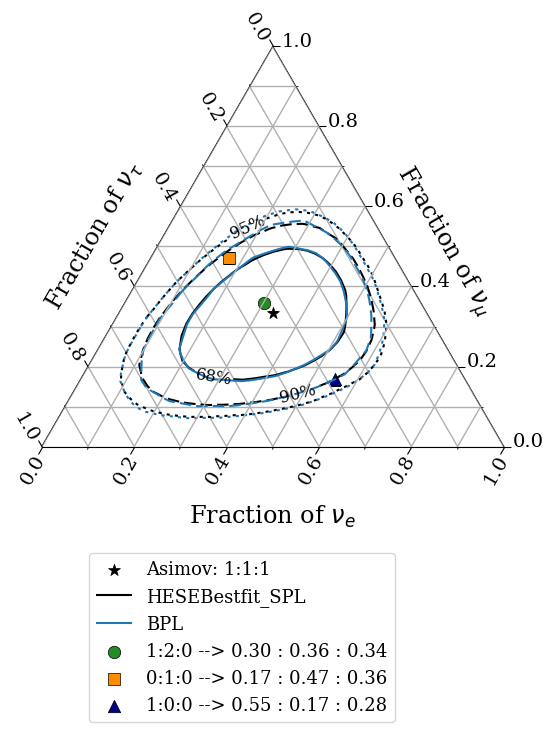

In [38]:
savename = f"compareflux_hese_noinel"
names = [
f"hese_HESEBestfit_SPL_noinel_SAY",
f"hese_BPL_nosyst_SAY",
]
labels = [
    "HESEBestfit_SPL",
    "BPL",
]
C = compare_contours( data = data,
                names = names,
                labels = labels,
                levels = ["68%","90%","95%"],
                title = "",
                scenarios = True,
                show_ts_labels=True,
                savepath = f"{plotting_path}/{savename}.png")

for name in names: compare_area( C, alt_key=name, base_key=names[0], levels=["68%"] )